# Testing Mixed GLMs

In this notebook, we test a mixed GLM with an interaction term:

**Model**: A = b0 + b1*B + b2*C + b3*B*C

Where:
- A and B are real numbers in [0, 1]
- C is binary (0 or 1)

We'll:
1. Generate synthetic data
2. Fit the mixed GLM and extract coefficients
3. Compare with separate simple models

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from helpers import *

# Set random seed for reproducibility
np.random.seed(42)

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-3dbb1q38 because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## Step 1: Generate Dataset

Generate 100 instances where:
- A = 0.5 * B (base relationship)
- C term shifts values by 1
- Add Gaussian noise

In [3]:
def generate_synthetic_data(b1=.5, b2=1, noise_level=0.1):
    # Generate data
    n_samples = 100

    # B: random values between 0 and 1
    B = np.random.uniform(0, 1, n_samples)

    # C: binary variable (0 or 1)
    C = np.random.choice([0, 1], n_samples)

    # A: based on the relationship A = 0.5*B + 1*C (shift by 1 when C=1)
    # Add some noise
    noise = np.random.normal(0, noise_level, n_samples)
    A = b1 * B + b2 * C + noise

    # Create DataFrame
    data = pd.DataFrame({
        'A': A,
        'B': B,
        'C': C
    })

    return data

data = generate_synthetic_data(b1=0.4, b2=1, noise_level=.1)

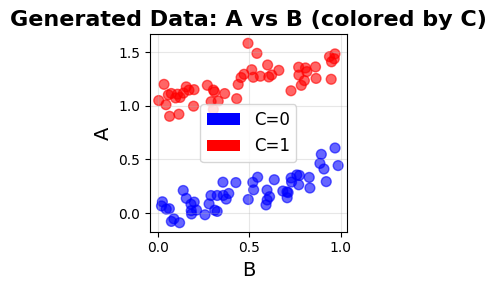

In [4]:
# Visualize the generated data
plt.figure(figsize=(3, 3))
colors = ['blue' if c == 0 else 'red' for c in data['C']]
plt.scatter(data['B'], data['A'], c=colors, alpha=0.6, s=50)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='C=0'),
                   Patch(facecolor='red', label='C=1')]
plt.legend(handles=legend_elements, fontsize=12)

plt.xlabel('B', fontsize=14)
plt.ylabel('A', fontsize=14)
plt.title('Generated Data: A vs B (colored by C)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2: Fit Mixed GLM

Fit the model: A = b0 + b1*B + b2*C + b3*B*C

Extract:
1. Slope for B (b1) when C=0 and C=1
2. Intercept when C=0 and C=1

In [5]:
results_mixed = fit_mixed_glm(data)
#show_mixed_glm_results(results_mixed)

## Statistical Tests

Perform the following tests for both methods:
1. Is b1 (slope for B) significantly non-zero for both C=0 and C=1?
2. Is b1 significantly between 0 and 1 for both C=0 and C=1?
3. Is the intercept significantly higher for C=1 compared to C=0?

In [6]:
test_results = stat_tests_mixed_glm(results_mixed)
test_results

{'slope_c0': 0.4351302135780194,
 'slope_c1': 0.3727160938768229,
 'intercept_c0': -0.01938618527975338,
 'intercept_c1': 1.039026924446356,
 'b1_c0_pvalue': 1.3486590551907331e-14,
 'b1_c0_significant': True,
 'b1_c1_pvalue': 2.4278357102502923e-12,
 'b1_c1_significant': True,
 'b1_c0_ci': (0.34009911214313426, 0.5301613150129045),
 'b1_c0_within_bounds': True,
 'b1_c1_ci': (0.2817673959572682, 0.46366479179637765),
 'b1_c1_within_bounds': True,
 'intercept_difference': 1.0584131097261094,
 'intercept_c1_higher': True}

## Visualization with GLM Fit Lines

Plot the data with the fitted lines from the mixed GLM model.

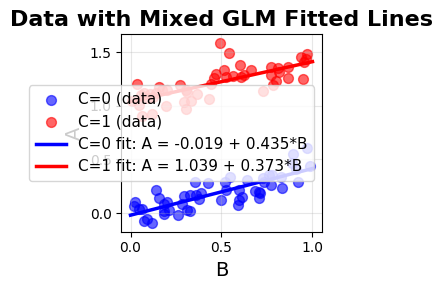


Fitted equations:
  C=0: A = -0.0194 + 0.4351*B
  C=1: A = 1.0390 + 0.3727*B


In [7]:
# Extract coefficients from mixed GLM
b0 = results_mixed.params['const']
b1 = results_mixed.params['B']
b2 = results_mixed.params['C']
b3 = results_mixed.params['B_C']

# Visualize the data with fitted lines
plt.figure(figsize=(3, 3))

# Separate data for plotting
data_c0 = data[data['C'] == 0]
data_c1 = data[data['C'] == 1]

# Plot the data points
plt.scatter(data_c0['B'], data_c0['A'], c='blue', alpha=0.6, s=50, label='C=0 (data)')
plt.scatter(data_c1['B'], data_c1['A'], c='red', alpha=0.6, s=50, label='C=1 (data)')

# Create B values for the fitted lines
B_range = np.linspace(0, 1, 100)

# Fitted line for C=0: A = b0 + b1*B
A_fit_c0 = b0 + b1 * B_range
plt.plot(B_range, A_fit_c0, 'b-', linewidth=2.5, 
         label=f'C=0 fit: A = {b0:.3f} + {b1:.3f}*B')

# Fitted line for C=1: A = (b0 + b2) + (b1 + b3)*B
A_fit_c1 = (b0 + b2) + (b1 + b3) * B_range
plt.plot(B_range, A_fit_c1, 'r-', linewidth=2.5, 
         label=f'C=1 fit: A = {b0+b2:.3f} + {b1+b3:.3f}*B')

plt.xlabel('B', fontsize=14)
plt.ylabel('A', fontsize=14)
plt.title('Data with Mixed GLM Fitted Lines', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFitted equations:")
print(f"  C=0: A = {b0:.4f} + {b1:.4f}*B")
print(f"  C=1: A = {b0+b2:.4f} + {b1+b3:.4f}*B")

In [11]:
hypothesis = add_hypothesis(test_results)

print("\nHypothesis based on test results:")
print(hypothesis)


Hypothesis based on test results:
Foraging
